In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

CARPETA = "/content/drive/MyDrive/Proyecto"
df = pd.read_csv(f"{CARPETA}/data/anemia_procesado.csv")
df.head()

,id,Age,Sex,RBC,PCV,MCV,MCH,MCHC,RDW,TLC,PLT,HGB,anemia,tipo_morfologico,severidad,grupo_edad
0,1.0,28.0,0.0,5.66,34.0,60.1,17.0,28.2,20.0,11.10,128.3,9.6,1,microcítica,moderada,11-30
1,2.0,41.0,0.0,4.78,44.5,93.1,28.9,31.0,13.0,7.02,419.0,13.8,0,normocítica,sin anemia,31-50
2,3.0,40.0,1.0,4.65,41.6,89.5,28.8,32.2,13.0,8.09,325.0,13.4,0,normocítica,sin anemia,31-50
3,4.0,76.0,0.0,4.24,36.7,86.6,26.7,30.8,14.9,13.41,264.0,11.3,1,normocítica,leve,71-89
4,5.0,20.0,1.0,4.14,36.9,89.1,27.8,31.2,13.2,4.75,196.0,11.5,1,normocítica,leve,11-30


In [9]:
# Variables predictoras: hemograma SIN la hemoglobina (que define el target)
features = ["Age", "Sex", "MCV", "MCHC", "RDW", "TLC", "PLT"]
X = df[features]
y = df["anemia"]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print("ROC-AUC por fold:", scores.round(3))
print("Media:", scores.mean().round(3), "±", scores.std().round(3))

ROC-AUC por fold: [0.553 0.704 0.64  0.748 0.747]
Media: 0.678 ± 0.074


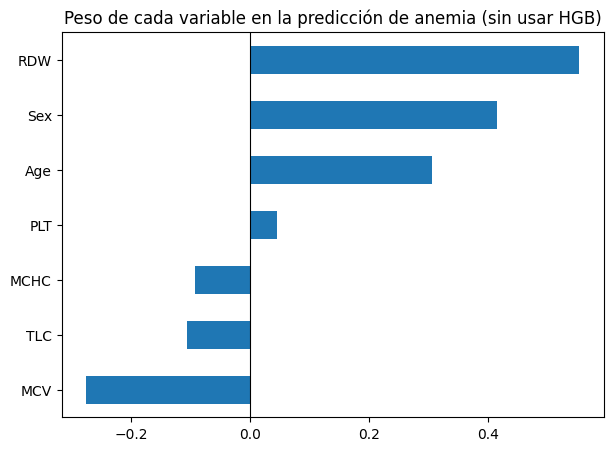

In [10]:
pipe.fit(X, y)
coefs = pd.Series(pipe.named_steps["clf"].coef_[0], index=features).sort_values()
coefs.plot(kind="barh", figsize=(7,5))
plt.title("Peso de cada variable en la predicción de anemia (sin usar HGB)")
plt.axvline(0, color="black", linewidth=0.8)
plt.savefig(f"{CARPETA}/figures/coeficientes_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

In [1]:
!pip freeze | grep -iE "^(pandas|numpy|matplotlib|seaborn|scikit-learn)="

matplotlib==3.10.0
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
seaborn==0.13.2
